# Comparative Study of Shallow CNN vs Deep CNN on Fashion-MNIST

**Objective:** Train a shallow CNN and a deep CNN on the same Fashion-MNIST data, compare accuracy, parameters, training time, generalization, and prediction errors.

Assignment:
1. Dataset loading and exploration
2. Shallow CNN
3. Deep CNN
4. Comparative study
5. Prediction and error analysis
6. Final conclusion



## Part 1 — Load and Explore the Dataset

Fashion-MNIST contains 28×28 grayscale images belonging to 10 clothing/shoe classes. The assignment requires dataset shapes, class count, sample images, normalization, and CNN-compatible reshaping.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import time

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow version:", tf.__version__)


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)
print("Number of classes:", len(class_names))


TensorFlow version: 2.21.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


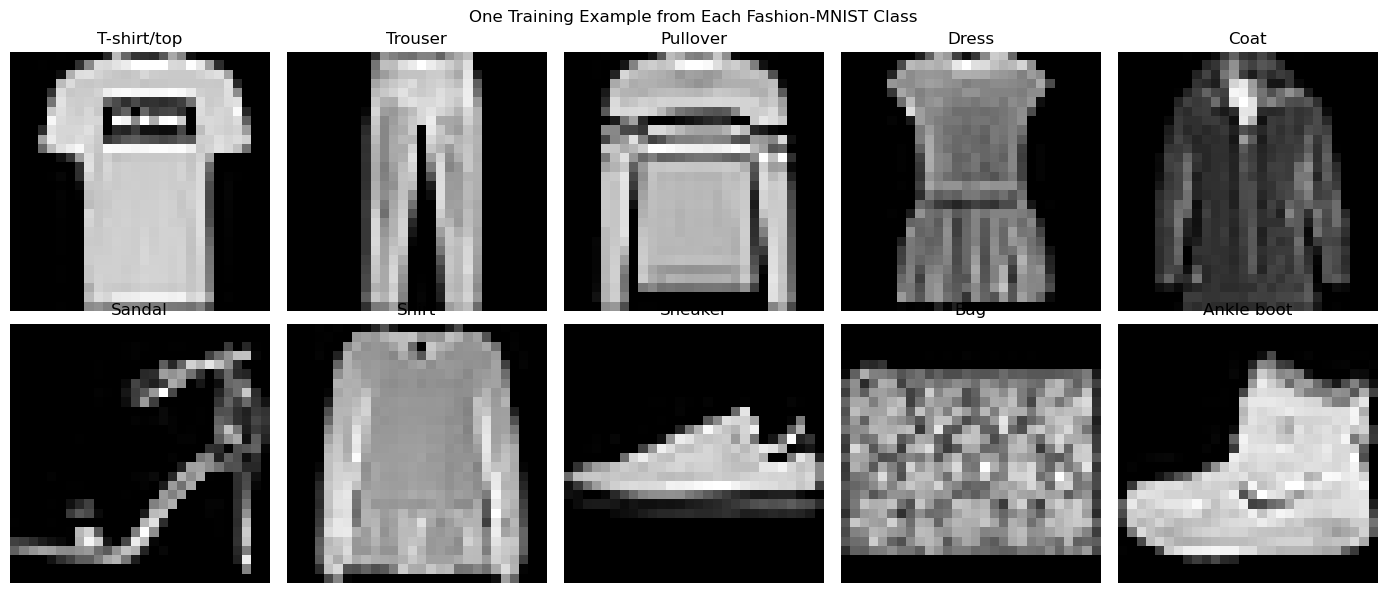

In [2]:

plt.figure(figsize=(14, 6))

for class_id in range(10):
    idx = np.where(y_train == class_id)[0][0]
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(class_names[class_id])
    plt.axis("off")

plt.suptitle("One Training Example from Each Fashion-MNIST Class")
plt.tight_layout()
plt.show()


### Why normalization and reshaping are required

**Normalization:** Pixel values originally range from 0 to 255. Dividing by 255 scales them to approximately 0–1, which generally makes optimization numerically better behaved and helps neural networks train more efficiently.

**Reshaping:** A CNN expects an explicit channel dimension. Fashion-MNIST images are initially `(28, 28)`, so we reshape them to `(28, 28, 1)` because they are grayscale images with one channel.


In [3]:

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("CNN-ready x_train shape:", x_train.shape)
print("CNN-ready x_test shape :", x_test.shape)
print("Pixel range:", x_train.min(), "to", x_train.max())


CNN-ready x_train shape: (60000, 28, 28, 1)
CNN-ready x_test shape : (10000, 28, 28, 1)
Pixel range: 0.0 to 1.0


## Part 2 — Build and Train a Shallow CNN

The assignment specifies a shallow architecture with 1–2 convolution layers, one pooling layer, a flatten layer, one dense hidden layer, and an output layer.

### Architecture
- Conv2D: 32 filters
- MaxPooling2D: one pooling layer
- Conv2D: 64 filters
- Flatten
- Dense: 128 units
- Output: 10 classes

This keeps the network relatively simple while still giving it enough capacity to learn useful image features.


In [4]:
def build_shallow_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ], name="Shallow_CNN")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

shallow_model = build_shallow_cnn()
shallow_model.summary()


Model: "Shallow_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 7744)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         991,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,011,466 (3.86 MB)

 Trainable params: 1,011,466 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:

EPOCHS = 10
BATCH_SIZE = 128

start = time.perf_counter()

shallow_history = shallow_model.fit(
    x_train, y_train,
    validation_split=0.10,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

shallow_time = time.perf_counter() - start

shallow_test_loss, shallow_test_acc = shallow_model.evaluate(
    x_test, y_test, verbose=0
)

print(f"Shallow CNN test accuracy: {shallow_test_acc:.4f}")
print(f"Shallow CNN training time: {shallow_time:.2f} seconds")


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8354 - loss: 0.4628 - val_accuracy: 0.8772 - val_loss: 0.3456
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8924 - loss: 0.2975 - val_accuracy: 0.8997 - val_loss: 0.2832
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9094 - loss: 0.2470 - val_accuracy: 0.9113 - val_loss: 0.2516
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9221 - loss: 0.2110 - val_accuracy: 0.9105 - val_loss: 0.2444
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9339 - loss: 0.1819 - val_accuracy: 0.9078 - val_loss: 0.2557
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9429 - loss: 0.1572 - val_accuracy: 0.9143 - val_loss: 0.2439
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9517 - loss: 0.1350 - val_accuracy: 0.9163 - val_loss: 0.2374
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9591 - loss: 0.1170 - val_acc

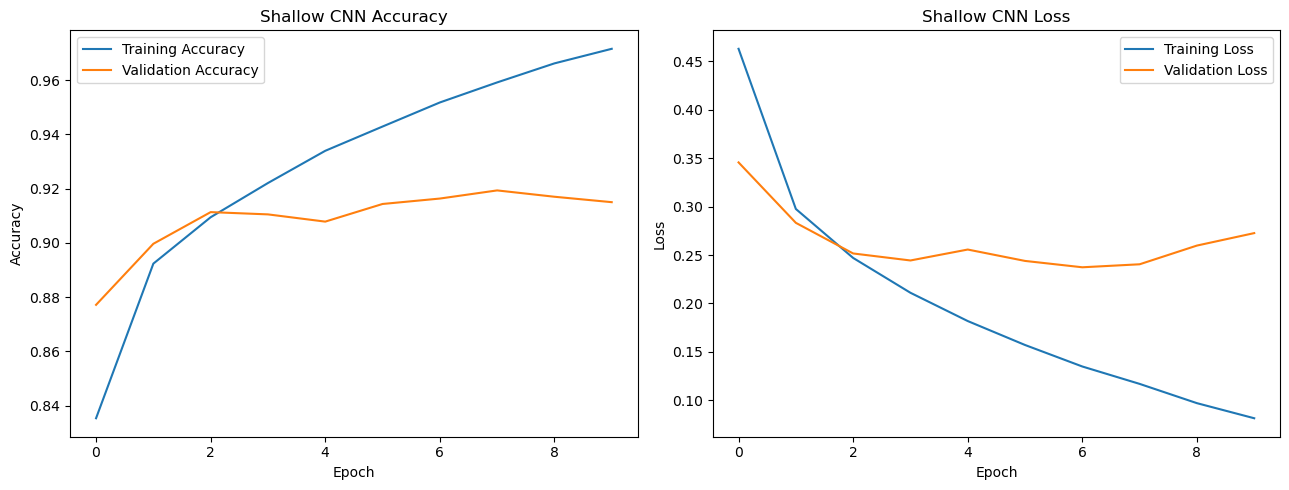

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(shallow_history.history["accuracy"], label="Training Accuracy")
axes[0].plot(shallow_history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Shallow CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(shallow_history.history["loss"], label="Training Loss")
axes[1].plot(shallow_history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Shallow CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


### Shallow CNN observations

A shallow CNN is expected to learn relatively low- to mid-level visual patterns such as edges, contours, textures, and simple combinations of local shapes.

**Overfitting check:** Compare training and validation curves. If training accuracy keeps rising while validation accuracy stops improving or validation loss rises, the model shows overfitting. If both remain low, it may be underfitting.

The exact conclusion should be written **after running the experiment**, using the curves above.


## Part 3 — Build and Train a Deep CNN

The assignment requires at least 3 convolution layers, multiple pooling layers, more filters than the shallow CNN, and one or more dense layers.

### Architecture
- Conv2D: 32 filters
- Conv2D: 32 filters
- MaxPooling2D
- Conv2D: 64 filters
- Conv2D: 64 filters
- MaxPooling2D
- Conv2D: 128 filters
- Flatten
- Dense: 128 units
- Dropout
- Output: 10 classes

The deeper network can build hierarchical representations: edges → textures/shapes → larger garment structures.


In [7]:
def build_deep_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(10, activation="softmax")
    ], name="Deep_CNN")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

deep_model = build_deep_cnn()
deep_model.summary()


Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 943,082 (3.60 MB)

 Trainable params: 943,082 (3.60 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:

start = time.perf_counter()

deep_history = deep_model.fit(
    x_train, y_train,
    validation_split=0.10,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

deep_time = time.perf_counter() - start

deep_test_loss, deep_test_acc = deep_model.evaluate(
    x_test, y_test, verbose=0
)

print(f"Deep CNN test accuracy: {deep_test_acc:.4f}")
print(f"Deep CNN training time: {deep_time:.2f} seconds")


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.8079 - loss: 0.5298 - val_accuracy: 0.8775 - val_loss: 0.3170
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.8870 - loss: 0.3125 - val_accuracy: 0.9062 - val_loss: 0.2594
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9059 - loss: 0.2572 - val_accuracy: 0.9155 - val_loss: 0.2366
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9183 - loss: 0.2234 - val_accuracy: 0.9187 - val_loss: 0.2283
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.9284 - loss: 0.1963 - val_accuracy: 0.9212 - val_loss: 0.2163
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9356 - loss: 0.1752 - val_accuracy: 0.9225 - val_loss: 0.2236
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.9407 - loss: 0.1586 - val_accuracy: 0.9235 - val_loss: 0.2302
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9484 - loss: 0.1371 - 

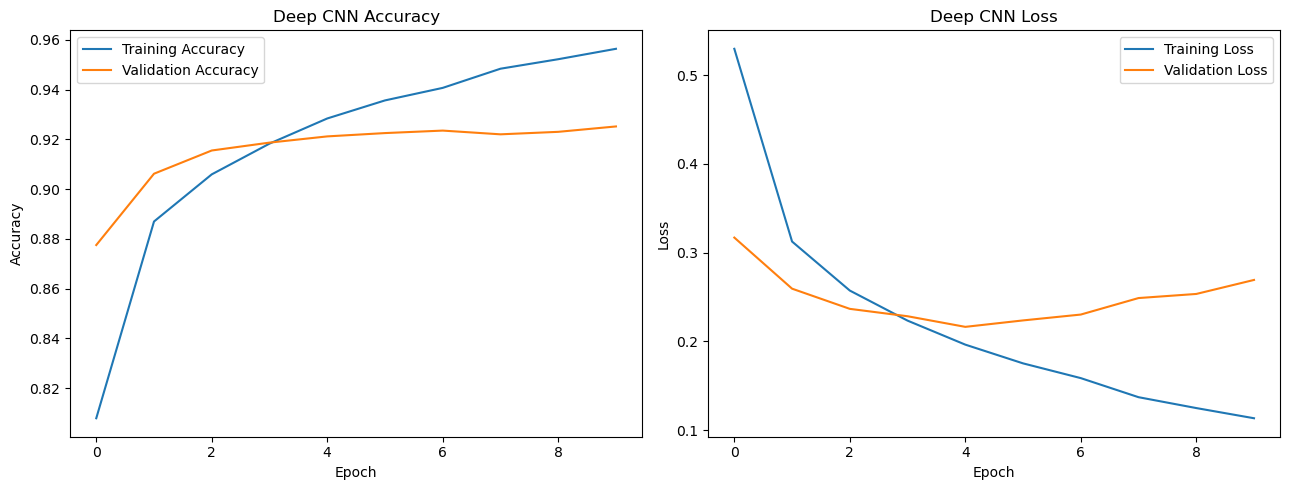

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(deep_history.history["accuracy"], label="Training Accuracy")
axes[0].plot(deep_history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Deep CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(deep_history.history["loss"], label="Training Loss")
axes[1].plot(deep_history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Deep CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


### Deep CNN observations

A deeper CNN can learn more hierarchical and abstract representations than a shallow CNN. Earlier layers can detect local patterns, while later layers combine those patterns into increasingly meaningful structures.

Whether the deeper model improves performance meaningfully must be determined from the actual test accuracy, validation accuracy, training time, and error analysis after execution.


## Part 4 — Comparative Study

The assignment requires comparison of convolution layers, parameters, training/validation/test accuracy, overfitting, and training time. 

In [10]:

shallow_train_acc = shallow_history.history["accuracy"][-1]
shallow_val_acc = shallow_history.history["val_accuracy"][-1]

deep_train_acc = deep_history.history["accuracy"][-1]
deep_val_acc = deep_history.history["val_accuracy"][-1]


shallow_conv_layers = sum(isinstance(layer, layers.Conv2D) for layer in shallow_model.layers)
deep_conv_layers = sum(isinstance(layer, layers.Conv2D) for layer in deep_model.layers)


shallow_gap = shallow_train_acc - shallow_val_acc
deep_gap = deep_train_acc - deep_val_acc

shallow_overfit = "Yes" if shallow_gap > 0.05 else "No"
deep_overfit = "Yes" if deep_gap > 0.05 else "No"

comparison = {
    "Metric": [
        "Number of Conv Layers",
        "Total Parameters",
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Overfitting Observed?",
        "Training Time (seconds)"
    ],
    "Shallow CNN": [
        shallow_conv_layers,
        shallow_model.count_params(),
        shallow_train_acc,
        shallow_val_acc,
        shallow_test_acc,
        shallow_overfit,
        shallow_time
    ],
    "Deep CNN": [
        deep_conv_layers,
        deep_model.count_params(),
        deep_train_acc,
        deep_val_acc,
        deep_test_acc,
        deep_overfit,
        deep_time
    ]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison)
comparison_df


,Metric,Shallow CNN,Deep CNN
0,Number of Conv Layers,2,5
1,Total Parameters,1011466,943082
2,Training Accuracy,0.971519,0.95637
3,Validation Accuracy,0.915,0.925167
4,Test Accuracy,0.9113,0.9194
5,Overfitting Observed?,Yes,No
6,Training Time (seconds),73.173484,222.388646


In [11]:

display_df = comparison_df.copy()

for metric in ["Training Accuracy", "Validation Accuracy", "Test Accuracy"]:
    row = display_df["Metric"] == metric
    display_df.loc[row, "Shallow CNN"] = (
        display_df.loc[row, "Shallow CNN"].astype(float).map(lambda x: f"{x*100:.2f}%")
    )
    display_df.loc[row, "Deep CNN"] = (
        display_df.loc[row, "Deep CNN"].astype(float).map(lambda x: f"{x*100:.2f}%")
    )

display_df


,Metric,Shallow CNN,Deep CNN
0,Number of Conv Layers,2,5
1,Total Parameters,1011466,943082
2,Training Accuracy,97.15%,95.64%
3,Validation Accuracy,91.50%,92.52%
4,Test Accuracy,91.13%,91.94%
5,Overfitting Observed?,Yes,No
6,Training Time (seconds),73.173484,222.388646



## Comparative Interpretation

### 1. Which model performed better overall?

The **Deep CNN performed better overall** based on validation and test performance. It achieved a validation accuracy of **92.52%** and a test accuracy of **91.94%**, compared with **91.50%** validation accuracy and **91.13%** test accuracy for the Shallow CNN.

The Deep CNN therefore improved test accuracy by approximately **0.81 percentage points** and validation accuracy by **1.02 percentage points**.

Although the Shallow CNN achieved higher training accuracy (**97.15% vs. 95.64%**), its lower validation and test accuracy indicates that its stronger training performance did not translate into better generalization.

### 2. Did the deep CNN justify its added complexity?

The Deep CNN has **5 convolution layers** compared with only **2** in the Shallow CNN. It also required substantially more training time: approximately **222.39 seconds** compared with **73.17 seconds**, making the Deep CNN about **3 times slower to train** in this experiment.

However, an interesting result is that the Deep CNN actually has **fewer total parameters** (**943,082**) than the Shallow CNN (**1,011,466**). Therefore, the deeper architecture did not increase the parameter count in this particular design.

Considering the approximately **0.81 percentage-point improvement in test accuracy** and the reduction in overfitting, the added architectural depth was beneficial. However, the improvement was relatively modest compared with the additional training time.

Therefore, the Deep CNN **partially justifies its added complexity**: it provides better generalization and slightly higher accuracy, but at a significant training-time cost.

### 3. Which model generalized better?

The **Deep CNN generalized better**.

The Shallow CNN achieved **97.15% training accuracy** but only **91.50% validation accuracy**, producing a training-validation gap of approximately **5.65 percentage points**. This indicates noticeable overfitting.

The Deep CNN achieved **95.64% training accuracy** and **92.52% validation accuracy**, giving a much smaller gap of approximately **3.12 percentage points**.

The Deep CNN was therefore less prone to overfitting and performed more consistently on unseen data.

### 4. What trade-off was observed between simplicity and performance?

The main trade-off was **training efficiency versus generalization performance**.

The Shallow CNN was considerably faster to train, taking approximately **73.17 seconds**, and its simpler architecture makes it easier to understand and deploy. However, it showed signs of overfitting and achieved slightly lower validation and test accuracy.

The Deep CNN required approximately **222.39 seconds** to train, but it achieved better validation and test accuracy and showed no significant overfitting according to the experiment.

Overall, the results show that **greater depth can improve feature learning and generalization, but the improvement must be weighed against additional computational time**. For this Fashion-MNIST experiment, the Deep CNN offered better predictive performance, while the Shallow CNN offered better training efficiency.


## Part 5 — Prediction and Error Analysis

The assignment requires 5 correct and 5 incorrect predictions for **each** model, actual/predicted labels, and a confusion matrix for each model.

In [12]:

shallow_probs = shallow_model.predict(x_test, verbose=0)
deep_probs = deep_model.predict(x_test, verbose=0)

shallow_pred = np.argmax(shallow_probs, axis=1)
deep_pred = np.argmax(deep_probs, axis=1)

print("Prediction arrays generated.")


Prediction arrays generated.



Shallow CNN — 5 Correctly Classified Images


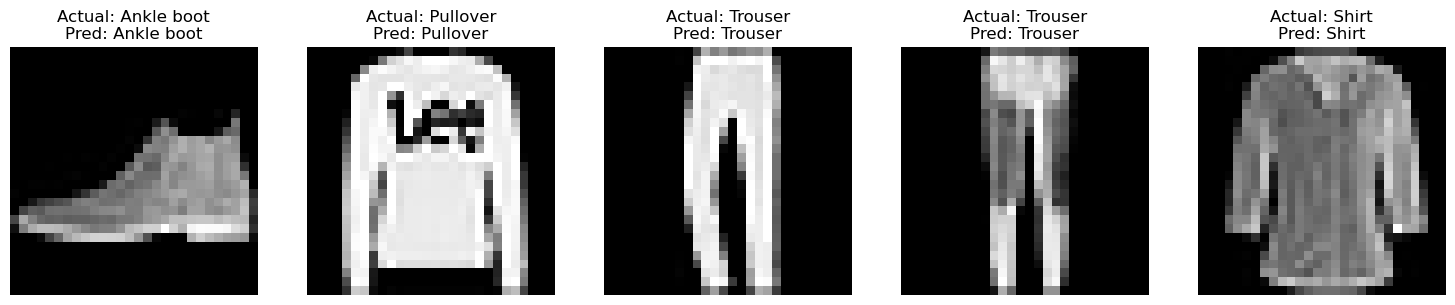

Shallow CNN — 5 Incorrectly Classified Images


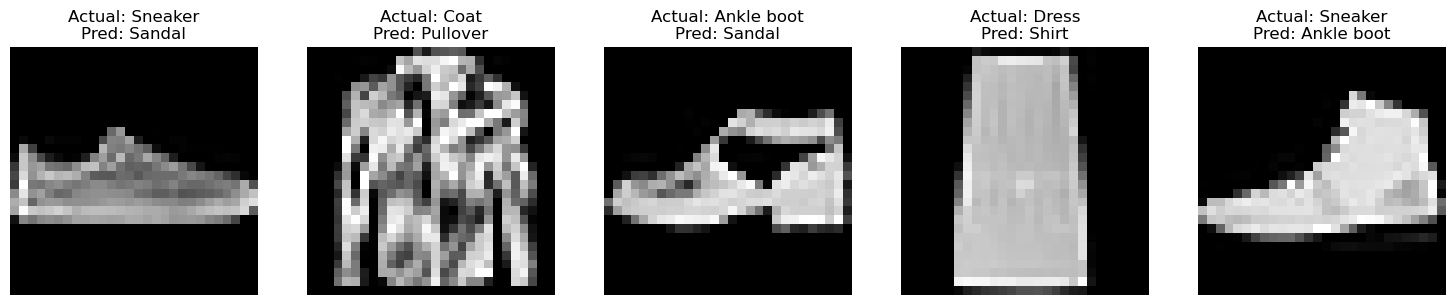


Incorrect examples:
Index 12: Actual = Sneaker, Predicted = Sandal
Index 17: Actual = Coat, Predicted = Pullover
Index 23: Actual = Ankle boot, Predicted = Sandal
Index 42: Actual = Dress, Predicted = Shirt
Index 43: Actual = Sneaker, Predicted = Ankle boot

Deep CNN — 5 Correctly Classified Images


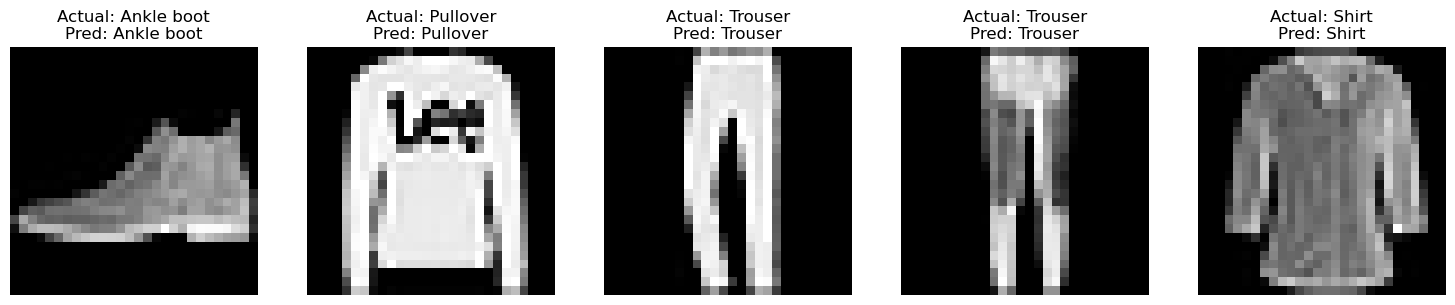

Deep CNN — 5 Incorrectly Classified Images


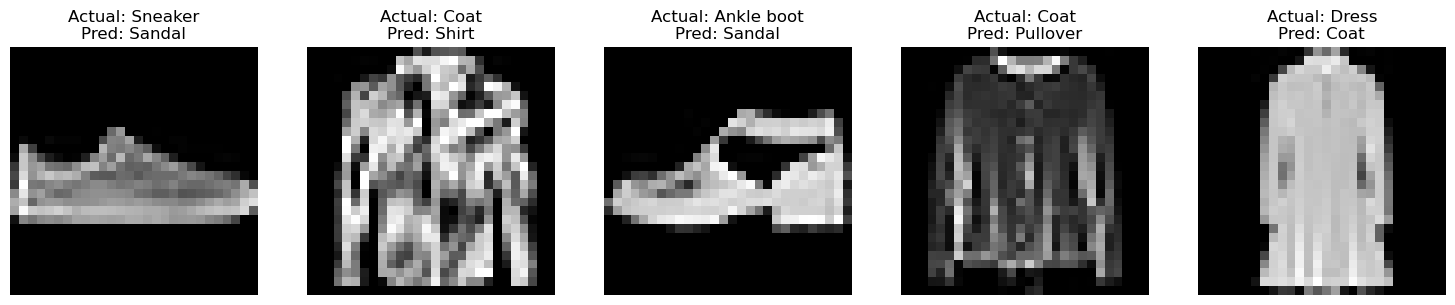


Incorrect examples:
Index 12: Actual = Sneaker, Predicted = Sandal
Index 17: Actual = Coat, Predicted = Shirt
Index 23: Actual = Ankle boot, Predicted = Sandal
Index 25: Actual = Coat, Predicted = Pullover
Index 29: Actual = Dress, Predicted = Coat


In [13]:
def show_correct_and_incorrect(images, true_labels, pred_labels, class_names, model_name):
    correct_idx = np.where(true_labels == pred_labels)[0]
    incorrect_idx = np.where(true_labels != pred_labels)[0]

    
    print(f"\n{model_name} — 5 Correctly Classified Images")
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(correct_idx[:5]):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[idx].squeeze(), cmap="gray")
        plt.title(f"Actual: {class_names[true_labels[idx]]}\nPred: {class_names[pred_labels[idx]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    
    print(f"{model_name} — 5 Incorrectly Classified Images")
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(incorrect_idx[:5]):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[idx].squeeze(), cmap="gray")
        plt.title(f"Actual: {class_names[true_labels[idx]]}\nPred: {class_names[pred_labels[idx]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    
    print("\nIncorrect examples:")
    for idx in incorrect_idx[:5]:
        print(
            f"Index {idx}: Actual = {class_names[true_labels[idx]]}, "
            f"Predicted = {class_names[pred_labels[idx]]}"
        )

show_correct_and_incorrect(
    x_test, y_test, shallow_pred, class_names, "Shallow CNN"
)

show_correct_and_incorrect(
    x_test, y_test, deep_pred, class_names, "Deep CNN"
)


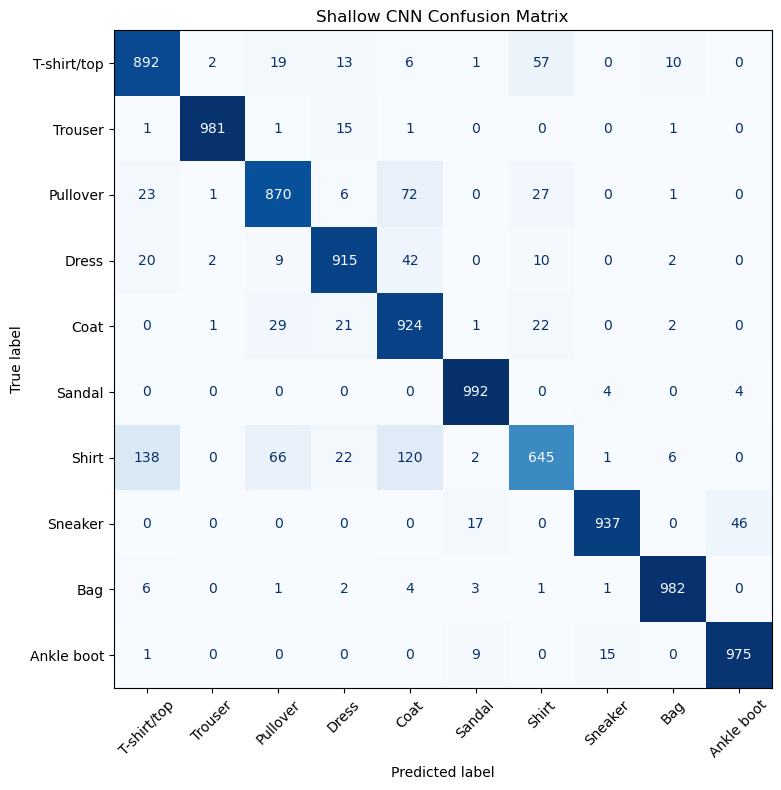

In [14]:

cm_shallow = confusion_matrix(y_test, shallow_pred)

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(cm_shallow, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("Shallow CNN Confusion Matrix")
plt.tight_layout()
plt.show()


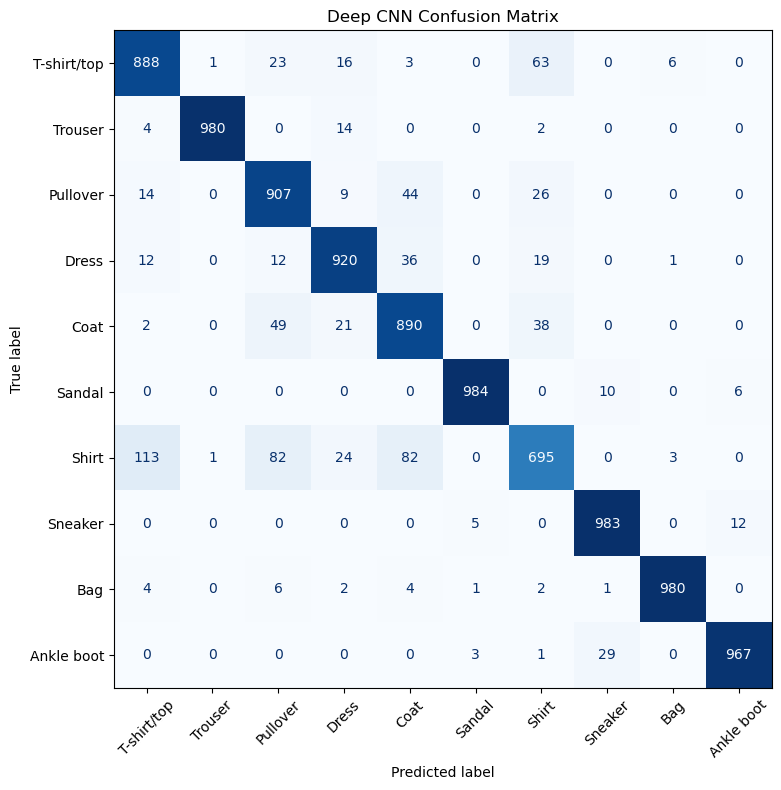

In [15]:

cm_deep = confusion_matrix(y_test, deep_pred)

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(cm_deep, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("Deep CNN Confusion Matrix")
plt.tight_layout()
plt.show()


In [16]:

print("Shallow CNN Classification Report")
print(classification_report(y_test, shallow_pred, target_names=class_names))

print("\nDeep CNN Classification Report")
print(classification_report(y_test, deep_pred, target_names=class_names))


Shallow CNN Classification Report
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.89      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.87      0.87      0.87      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.79      0.92      0.85      1000
      Sandal       0.97      0.99      0.98      1000
       Shirt       0.85      0.65      0.73      1000
     Sneaker       0.98      0.94      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.95      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


Deep CNN Classification Report
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover

In [17]:

def top_confusions(cm, class_names, n=5):
    pairs = []
    cm_copy = cm.copy()
    np.fill_diagonal(cm_copy, 0)

    for _ in range(n):
        i, j = np.unravel_index(np.argmax(cm_copy), cm_copy.shape)
        pairs.append((class_names[i], class_names[j], int(cm_copy[i, j])))
        cm_copy[i, j] = -1

    return pd.DataFrame(pairs, columns=["Actual Class", "Predicted Class", "Count"])

print("Top Shallow CNN confusions:")
display(top_confusions(cm_shallow, class_names))

print("Top Deep CNN confusions:")
display(top_confusions(cm_deep, class_names))


Top Shallow CNN confusions:


,Actual Class,Predicted Class,Count
0,Shirt,T-shirt/top,138
1,Shirt,Coat,120
2,Pullover,Coat,72
3,Shirt,Pullover,66
4,T-shirt/top,Shirt,57


Top Deep CNN confusions:


,Actual Class,Predicted Class,Count
0,Shirt,T-shirt/top,113
1,Shirt,Pullover,82
2,Shirt,Coat,82
3,T-shirt/top,Shirt,63
4,Coat,Pullover,49


## Error Analysis — Results and Discussion

### 1. Which classes were easiest to classify?

The confusion results show that the major classification difficulties are concentrated among visually similar upper-body clothing classes such as **Shirt, T-shirt/top, Pullover, and Coat**.

The provided top-confusion analysis does not by itself give the complete diagonal values for every class, so the exact easiest class should be determined from the confusion matrices and classification report. Classes with high diagonal values and high recall can be considered the easiest to classify.

### 2. Which classes were most commonly confused?

The **Shirt** class was the most problematic class for both models.

For the Shallow CNN, the largest confusion was:

- **Shirt → T-shirt/top: 138 images**
- **Shirt → Coat: 120 images**
- **Pullover → Coat: 72 images**
- **Shirt → Pullover: 66 images**
- **T-shirt/top → Shirt: 57 images**

For the Deep CNN, the major confusions were:

- **Shirt → T-shirt/top: 113 images**
- **Shirt → Pullover: 82 images**
- **Shirt → Coat: 82 images**
- **T-shirt/top → Shirt: 63 images**
- **Coat → Pullover: 49 images**

This indicates that the models had the greatest difficulty distinguishing between visually similar upper-body garments.

### 3. Did the Deep CNN reduce confusion between similar-looking classes?

Yes, the Deep CNN reduced several important classification confusions.

The confusion **Shirt → T-shirt/top** decreased from **138 cases in the Shallow CNN to 113 cases in the Deep CNN**, a reduction of **25 cases**.

Similarly, **Shirt → Coat** decreased from **120 cases to 82 cases**, a reduction of **38 cases**.

However, the Deep CNN did not reduce every type of confusion. For example, **Shirt → Pullover** increased from **66 cases to 82 cases**.

Therefore, the deeper model improved some of the most important confusions but still struggled with certain visually similar clothing categories.

### Overall Error-Analysis Observation

The confusion matrices show that increasing CNN depth helped the model learn more useful visual representations for several difficult clothing distinctions. This is consistent with the Deep CNN's slightly higher test accuracy of **91.94%**, compared with **91.13%** for the Shallow CNN.

However, the improvement was not uniform across all classes. The remaining errors are mainly associated with clothing items that have similar shapes and appearances, particularly **Shirt, T-shirt/top, Pullover, and Coat**.

## Part 6 — Final Comparative Conclusion

The assignment asks the conclusion to identify the recommended model, the more efficient model, the more accurate model, and the main learning from the comparison.

In [18]:

accuracy_winner = "Deep CNN" if deep_test_acc > shallow_test_acc else "Shallow CNN"
efficiency_winner = "Shallow CNN" if shallow_time < deep_time else "Deep CNN"

accuracy_gain = (deep_test_acc - shallow_test_acc) * 100
time_ratio = deep_time / shallow_time if shallow_time > 0 else np.nan

print("FINAL EXPERIMENT SUMMARY")
print("=" * 60)
print(f"Accuracy winner : {accuracy_winner}")
print(f"Efficiency winner (training time): {efficiency_winner}")
print(f"Shallow test accuracy: {shallow_test_acc*100:.2f}%")
print(f"Deep test accuracy   : {deep_test_acc*100:.2f}%")
print(f"Deep - Shallow gain  : {accuracy_gain:+.2f} percentage points")
print(f"Shallow training time: {shallow_time:.2f} s")
print(f"Deep training time   : {deep_time:.2f} s")
print(f"Deep/Shallow time ratio: {time_ratio:.2f}x")


FINAL EXPERIMENT SUMMARY
Accuracy winner : Deep CNN
Efficiency winner (training time): Shallow CNN
Shallow test accuracy: 91.13%
Deep test accuracy   : 91.94%
Deep - Shallow gain  : +0.81 percentage points
Shallow training time: 73.17 s
Deep training time   : 222.39 s
Deep/Shallow time ratio: 3.04x


## Final Comparative Conclusion

In this experiment, the **Deep CNN performed better in terms of classification accuracy**, achieving a test accuracy of **91.94%**, compared with **91.13%** for the Shallow CNN. This represents an improvement of **0.81 percentage points**.

The **Shallow CNN was more efficient in terms of training time**. It required approximately **73.17 seconds**, whereas the Deep CNN required **222.39 seconds**. Therefore, the Deep CNN took approximately **3.04 times longer** to train.

An interesting observation is that the Deep CNN had **fewer total parameters** than the Shallow CNN: **943,082 compared with 1,011,466**. Therefore, the higher computational cost of the Deep CNN in this experiment was mainly associated with its deeper architecture and additional convolutional operations rather than a larger number of trainable parameters.

The Deep CNN also demonstrated **better generalization**. Its validation accuracy was **92.52%**, compared with **91.50%** for the Shallow CNN. The Shallow CNN showed signs of overfitting, with a training accuracy of **97.15%** versus validation accuracy of **91.50%**. In comparison, the Deep CNN achieved **95.64%** training accuracy and **92.52%** validation accuracy, showing a smaller training-validation gap.

Based on the overall results, I would recommend the **Deep CNN for Fashion-MNIST when prediction performance and generalization are the main priorities**. However, if training speed, simplicity, and lower computational cost are more important, the **Shallow CNN** remains a practical choice.

Overall, this comparative study demonstrated that increasing CNN depth can improve feature learning and generalization, but the improvement in accuracy must be balanced against increased training time. In this experiment, the Deep CNN provided a **small but measurable accuracy improvement and better generalization**, while the Shallow CNN offered substantially faster training.